In [31]:
# Parameters
ID <- NULL

In [32]:
TILE_NUM = ID

# Using forest age and history to examine the direction of current AGB density patterns in boreal

```bash
papermill /projects/code/maap_tools/notebooks/boreal_dynamics_plot_v2.ipynb $OUTDIR/boreal_dynamics_plot_v2_$TILE_NUM.ipynb -p TILE_NUM $TILE_NUM OUTDIR $ OUTDIR --kernel ir
```

```bash
pip install papermill
TILE_LIST='1154 2000 3460 2675'
for TILE_NUM in $TILE_LIST; do
    echo $TILE_NUM
    papermill /projects/code/maap_tools/notebooks/boreal_dynamics_tile_plots.ipynb /projects/code/maap_tools/notebooks/boreal_dynamics_tile_plots_$TILE_NUM.ipynb -p ID $TILE_NUM --kernel ir
done
```

## Plotting with dataframe from `boreal_dynamics_tile.ipynb`

i hate plotnine, so i have to do this

In [33]:
library(tidyverse)
library(patchwork)

In [46]:
#TILE_NUM = 3460 
MAIN_DIR = '/projects/my-public-bucket/local_output/extent_stack_boreal_fire/output/build_stack_clips'

In [47]:
stack_df = read_csv(paste0(MAIN_DIR, '/boreal_dynamics_trees_',TILE_NUM,'.csv'))

New names:
• `` -> `...1`
Rows: 7143840 Columns: 14
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (6): LC, Age_class, TCC_trend_class, TCC_trend_pval_class, TCC2020_class...
dbl (8): ...1, Mg_ha, Mg_C_ha_yr, TCC_trend, TCC_2020, TCC_trend_pval, Decid...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [48]:
stack_df_smry = read_csv(paste0(MAIN_DIR, '/boreal_dynamics_trees_',TILE_NUM,'_smry.csv'))

New names:
• `` -> `...1`
Rows: 2400 Columns: 20
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (6): LC, Age_class, TCC_trend_class, TCC_trend_pval_class, TCC2020_clas...
dbl (14): ...1, Mg sum, Mg_ha sum, TCC_2020 min, TCC_2020 max, TCC_2020 medi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [49]:
levels(factor(stack_df_smry$TCC_trend_pval_class))

[1] "not sig"      "sig (p<0.05)"

### Set factor order

In [50]:
levels(factor(stack_df$TCC_trend_class))

[1] "decline\n(strong)"  "decline\n(weak)"    "increase\n(strong)"
[4] "increase\n(weak)"   "stable"

In [51]:
classes_tcctrend = c('decline\n(strong)','decline\n(weak)','stable','increase\n(weak)','increase\n(strong)')
colors_tcctrend = c('#a6611a','#dfc27d','#f5f5f5','#80cdc1','#018571')
stack_df$TCC_trend_class = factor(stack_df$TCC_trend_class , levels=classes_tcctrend)
stack_df_smry$TCC_trend_class = factor(stack_df_smry$TCC_trend_class , levels=classes_tcctrend)
levels(factor(stack_df$TCC_trend_class))

[1] "decline\n(strong)"  "decline\n(weak)"    "stable"            
[4] "increase\n(weak)"   "increase\n(strong)"

In [52]:
levels(factor(stack_df$Age_class))

[1] "mature forest"     "non-forest"        "old-growth forest"
[4] "young forest"

In [53]:
classes_age = c('non-forest', 're-growth forest','young forest', 'mature forest','old-growth forest')
stack_df$Age_class = factor(stack_df$Age_class , levels=classes_age)
stack_df_smry$Age_class = factor(stack_df_smry$Age_class , levels=classes_age)
levels(factor(stack_df$Age_class))
levels(factor(stack_df_smry$Age_class))

[1] "non-forest"    "young forest"  "mature forest"

[1] "non-forest"    "young forest"  "mature forest"

In [54]:
levels(factor(stack_df_smry$TCC2020_class))

[1] "<20%"  ">=20%"

In [55]:
classes_tcc = c('>=20%','<20%')
stack_df$TCC2020_class = factor(stack_df$TCC2020_class , levels=classes_tcc)
stack_df_smry$TCC2020_class = factor(stack_df_smry$TCC2020_class , levels=classes_tcc)
levels(stack_df$TCC2020_class)

[1] ">=20%" "<20%"

In [56]:
# Forest/stand age
names_standage  = classes_age
colors_standage = c('gray','#e41a1c','#d9ef8b', '#5aae61', '#1b7837')

names(colors_standage) <- names_standage

# ESA Worldcover
names_worldcover = c( 'Trees', 'Shrubland', 'Grassland','Cropland',
                    'Built-up',
                    'Barren/sparse','Snow and ice','Open water','Herbaceous wetland','Mangroves','Moss and lichen', 'NA')
colors_worldcover = c( "#006400","#ffbb22","#ffff4c","#f096ff",
                   "#fa0000",
                   "#b4b4b4","#f0f0f0","#0064c8","#0096a0","#00cf75","#fae6a0",'gray')
names(colors_worldcover) <- names_worldcover

# TCC
names_tcc  = classes_tcc
colors_tcc = c('forestgreen','limegreen')
names(colors_tcc) <- names_tcc

# Decid Frac Prediction
names_decidpred = c('conifer', 'mixed', 'deciduous')
colors_decidpred = c('#5e3c99','#fdb863','#ffffbf')
names(colors_decidpred) = names_decidpred

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


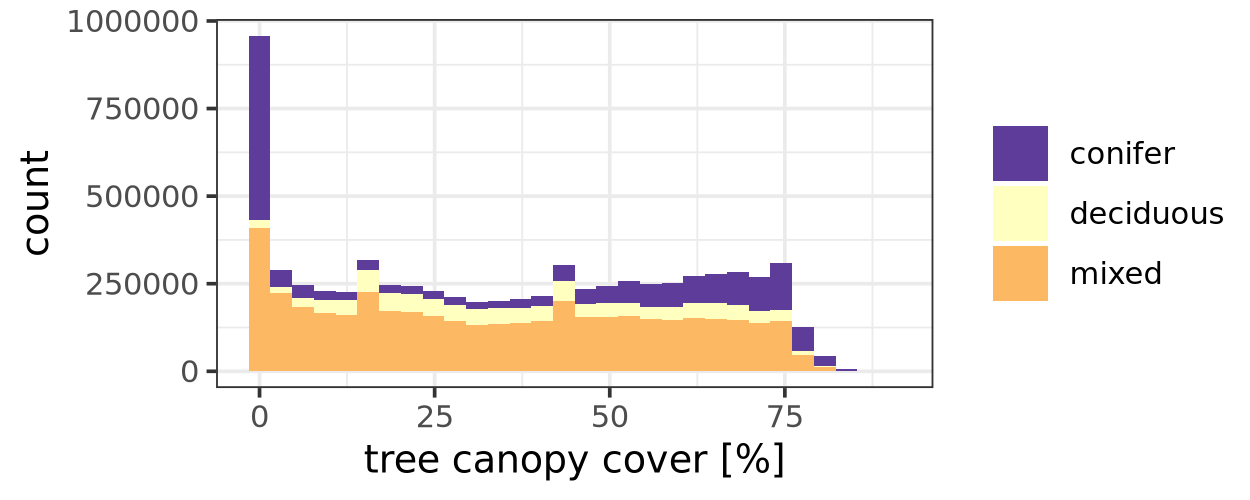

In [57]:
options(repr.plot.width = 5, repr.plot.height = 2, repr.plot.res = 250)

ggplot(stack_df, aes(TCC_2020, fill=DecidPred2015_class) ) +
    geom_histogram() +
    scale_fill_manual(values=colors_decidpred, name=NULL) +
    labs(x='tree canopy cover [%]') +
    theme_bw()

In [14]:
dim(stack_df) # should be 9 million or less per 90km tile

[1] 8109903      14

## Basic bar plots to understand proportions

#### Age class bars by LC class explain 'non-forest' designation

~10-30% trees?

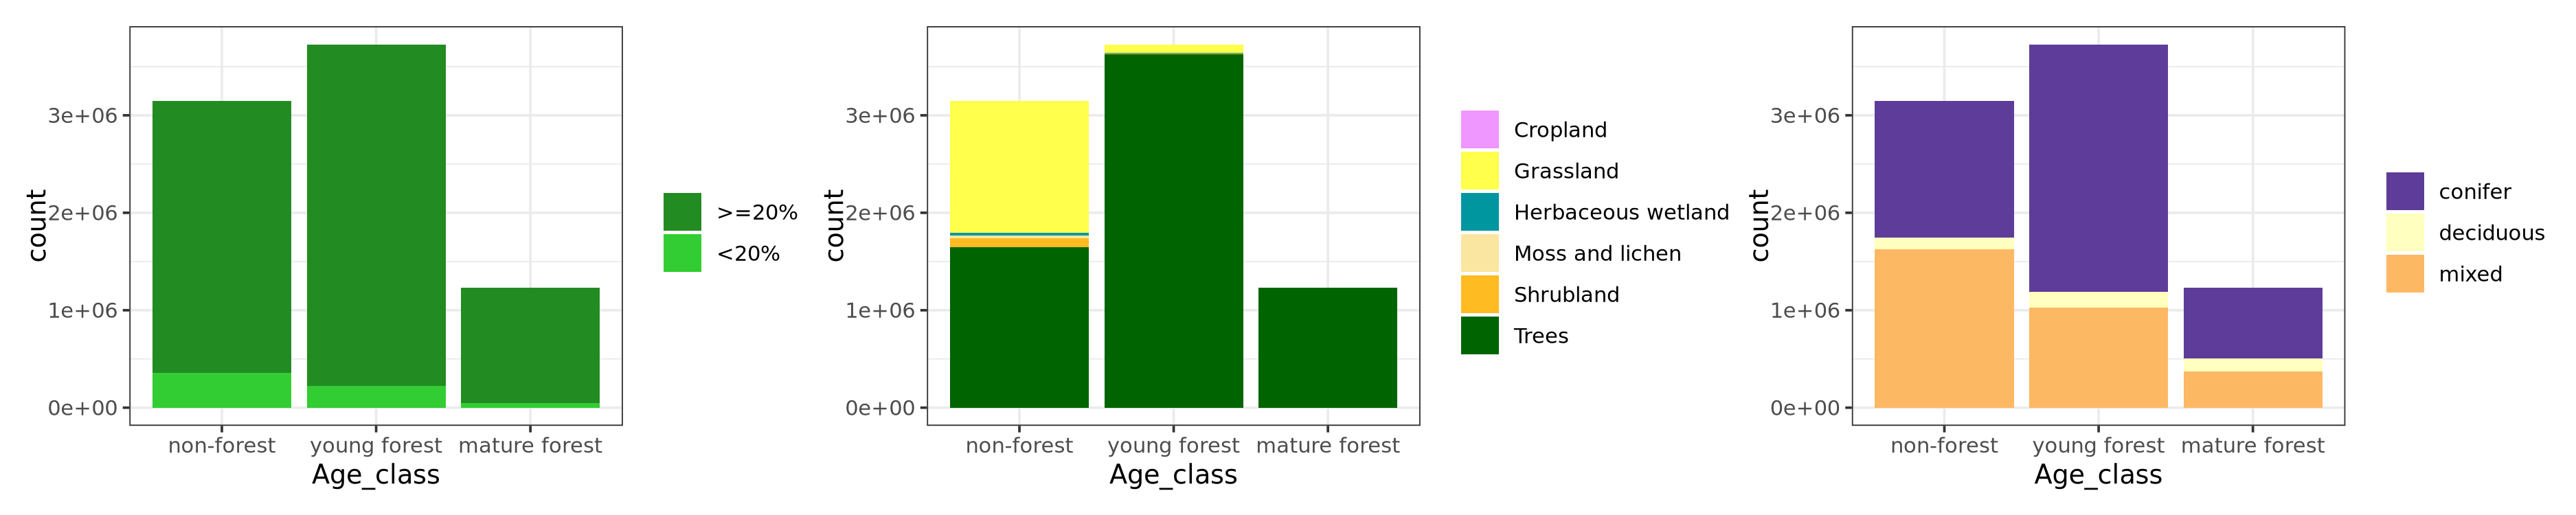

In [15]:
options(repr.plot.width = 15, repr.plot.height = 3, repr.plot.res = 250)

p_bars_tcc_age = ggplot(stack_df, aes( x=Age_class, fill=TCC2020_class) ) +
    geom_bar(stat='count') +
    scale_fill_manual(values=colors_tcc, name=NULL)+ 
    theme_bw()

p_bars_lc_age = ggplot(stack_df, aes( x=Age_class, fill=LC) ) + 
    geom_bar(stat='count') +
    scale_fill_manual(values=colors_worldcover, name=NULL)+ 
    theme_bw()

p_bars_decidfrac_age = ggplot(stack_df, aes( x=Age_class, fill=DecidPred2015_class) ) + 
    geom_bar(stat='count') +
    scale_fill_manual(values=colors_decidpred, name=NULL)+ 
    theme_bw()

p_bars_tcc_age + p_bars_lc_age + p_bars_decidfrac_age

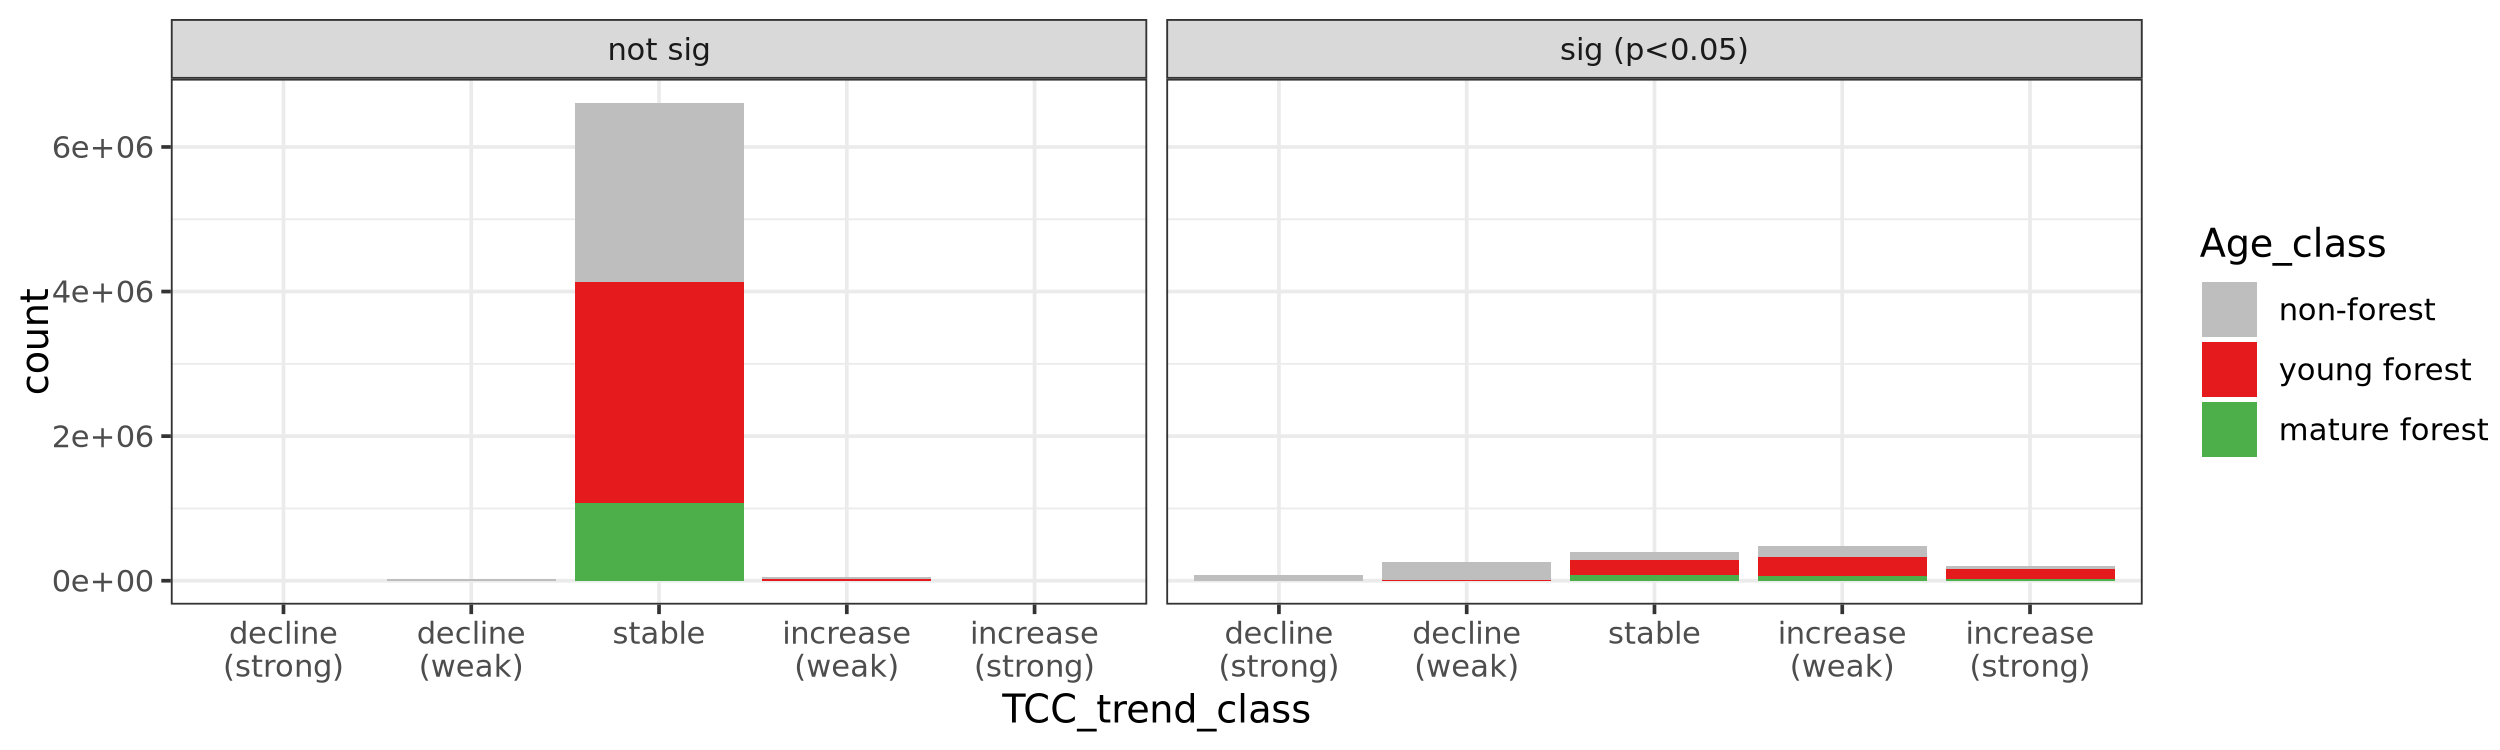

In [16]:
options(repr.plot.width = 10, repr.plot.height = 3, repr.plot.res = 250)

p_bars_age_trend = ggplot(stack_df, aes( x=TCC_trend_class, fill=Age_class) ) +
    geom_bar(stat='count') + # for a regular bar plot - fast
    scale_fill_manual(values=colors_standage, name='Age class')+ 
    facet_wrap(.~ TCC_trend_pval_class, ncol=2) + 
    theme_bw()
p_bars_age_trend

### Check where LC is null

In [17]:
dim(stack_df[is.na(stack_df$LC),])

[1]  0 14

### Now filter out some LCs

In [18]:
LC_REMOVE_LIST = c('Open water', 'Barren/sparse', 'Built-up','Cropland','Snow and ice','Mangroves','NA')
LC_KEEP_LIST = c('Trees','Shrubs','Grassland')

In [19]:
LC_NOTREMOVED_LIST = names_worldcover[!(names_worldcover %in% LC_REMOVE_LIST)]

In [20]:
TMP_DF = stack_df %>% 
    filter(!(LC %in% LC_REMOVE_LIST)) %>%
    filter(!is.na(LC)) %>%
    mutate(LC = factor(LC)) %>%
    droplevels()
dim(TMP_DF)
# Remove unused levels

[1] 8109765      14

In [21]:
TMP_SMRY_DF = stack_df_smry %>% 
    filter(!(LC %in% LC_REMOVE_LIST)) %>%
    filter(!is.na(LC)) %>%
    mutate(LC = factor(LC)) %>%
    droplevels()
dim(TMP_SMRY_DF)

[1] 900  20

In [22]:
#TMP_DF$LC = factor(TMP_DF$LC , levels=LC_EXISTING_LIST)

levels(TMP_DF$LC)

[1] "Grassland"          "Herbaceous wetland" "Moss and lichen"   
[4] "Shrubland"          "Trees"

### Total Biomass in age classes x `TCC 2020` | `LC 2020` | `Decid. fraction 2015`

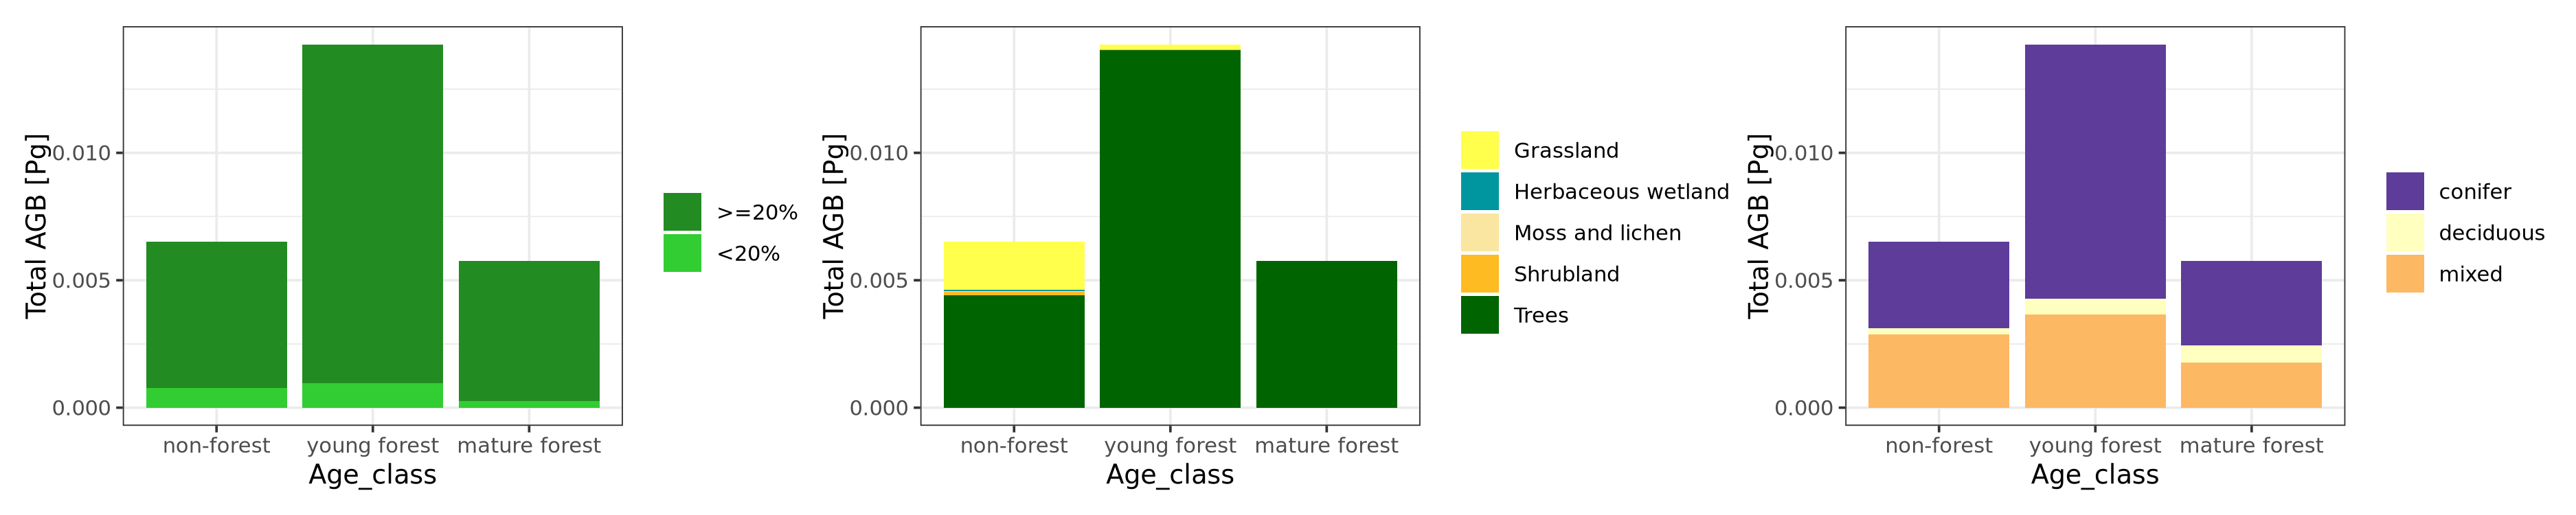

In [23]:
options(repr.plot.width = 15, repr.plot.height = 3, repr.plot.res = 250)

p_bar_totalAGB_tcc_age = ggplot(TMP_SMRY_DF, aes(y=`Total AGB [Pg]`, x=Age_class, fill=TCC2020_class) )  +
    geom_bar(stat='identity') +
    scale_fill_manual(values=colors_tcc, name=NULL) +
    theme_bw()

p_bar_totalAGB_LC_age = ggplot(TMP_SMRY_DF, aes(y=`Total AGB [Pg]`, x=Age_class, fill=LC) )  +
    geom_bar(stat='identity') +
    scale_fill_manual(values=colors_worldcover, name=NULL) +
    theme_bw()

p_bars_totalAGB_decidfrac_age = ggplot(TMP_SMRY_DF, aes(y=`Total AGB [Pg]`, x=Age_class, fill=DecidPred2015_class) ) + 
    geom_bar(stat='identity') +
    scale_fill_manual(values=colors_decidpred, name=NULL)+ 
    theme_bw()

p_bar_totalAGB_tcc_age + p_bar_totalAGB_LC_age + p_bars_totalAGB_decidfrac_age

In [24]:
# options(repr.plot.width =5, repr.plot.height = 3.5, repr.plot.res = 250)

# ggplot(TMP_SMRY_DF, aes(y=`Total AGB [Pg]`, x=Age_class, fill=Age_class) )  +
# geom_bar(stat='identity') +
# scale_fill_manual(values=colors_standage) +
# theme_bw()

#### AGB density varies by current age class and LC, and recent history

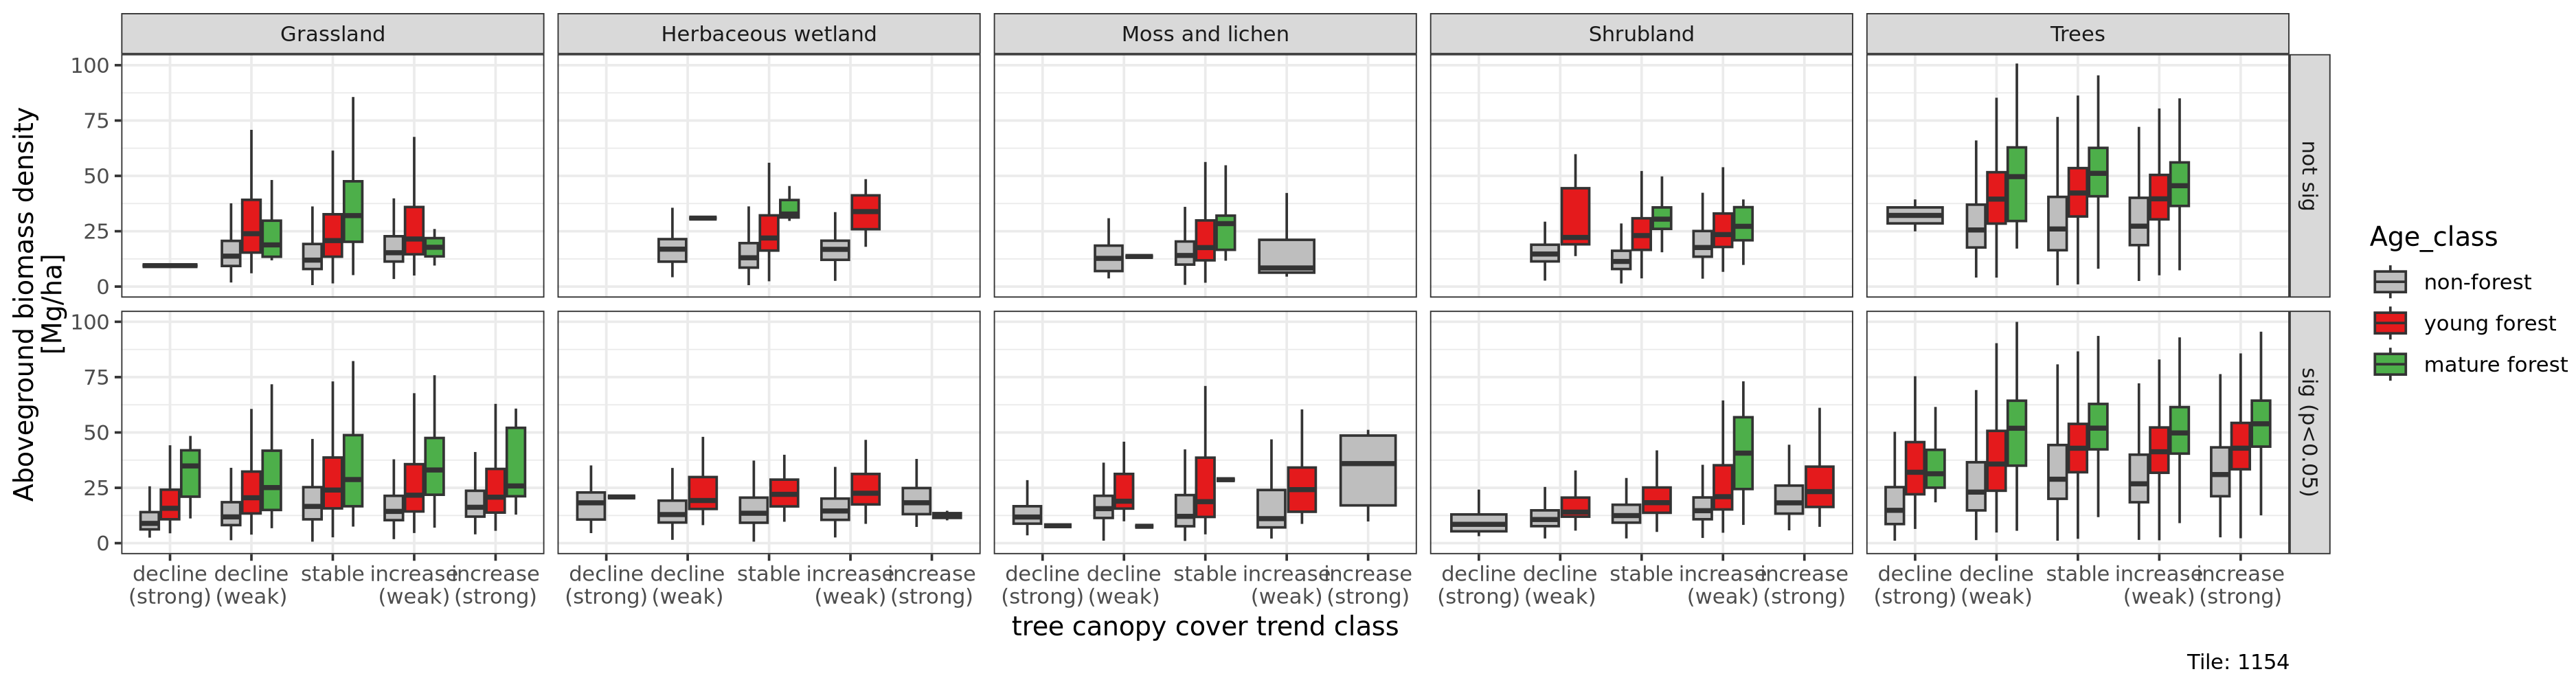

In [25]:
options(repr.plot.width = 15, repr.plot.height = 4, repr.plot.res = 250)

Y_VAR = 'Mg_ha'

ggplot(TMP_DF, aes( x=TCC_trend_class, y = .data[[Y_VAR]], fill=Age_class) ) + 
    geom_boxplot(outlier.shape=' ') + 
    scale_fill_manual(values=colors_standage, name='Age class')+ 
    coord_cartesian(ylim=c(0,100))+ 
    facet_grid(TCC_trend_pval_class ~ LC)+ 
    theme_bw() +
    labs(x='tree canopy cover trend class', y='Aboveground biomass density\n[Mg/ha]', caption=paste0('Tile: ',TILE_NUM))

#### C accumulation varies by current age class and LC, and recent history

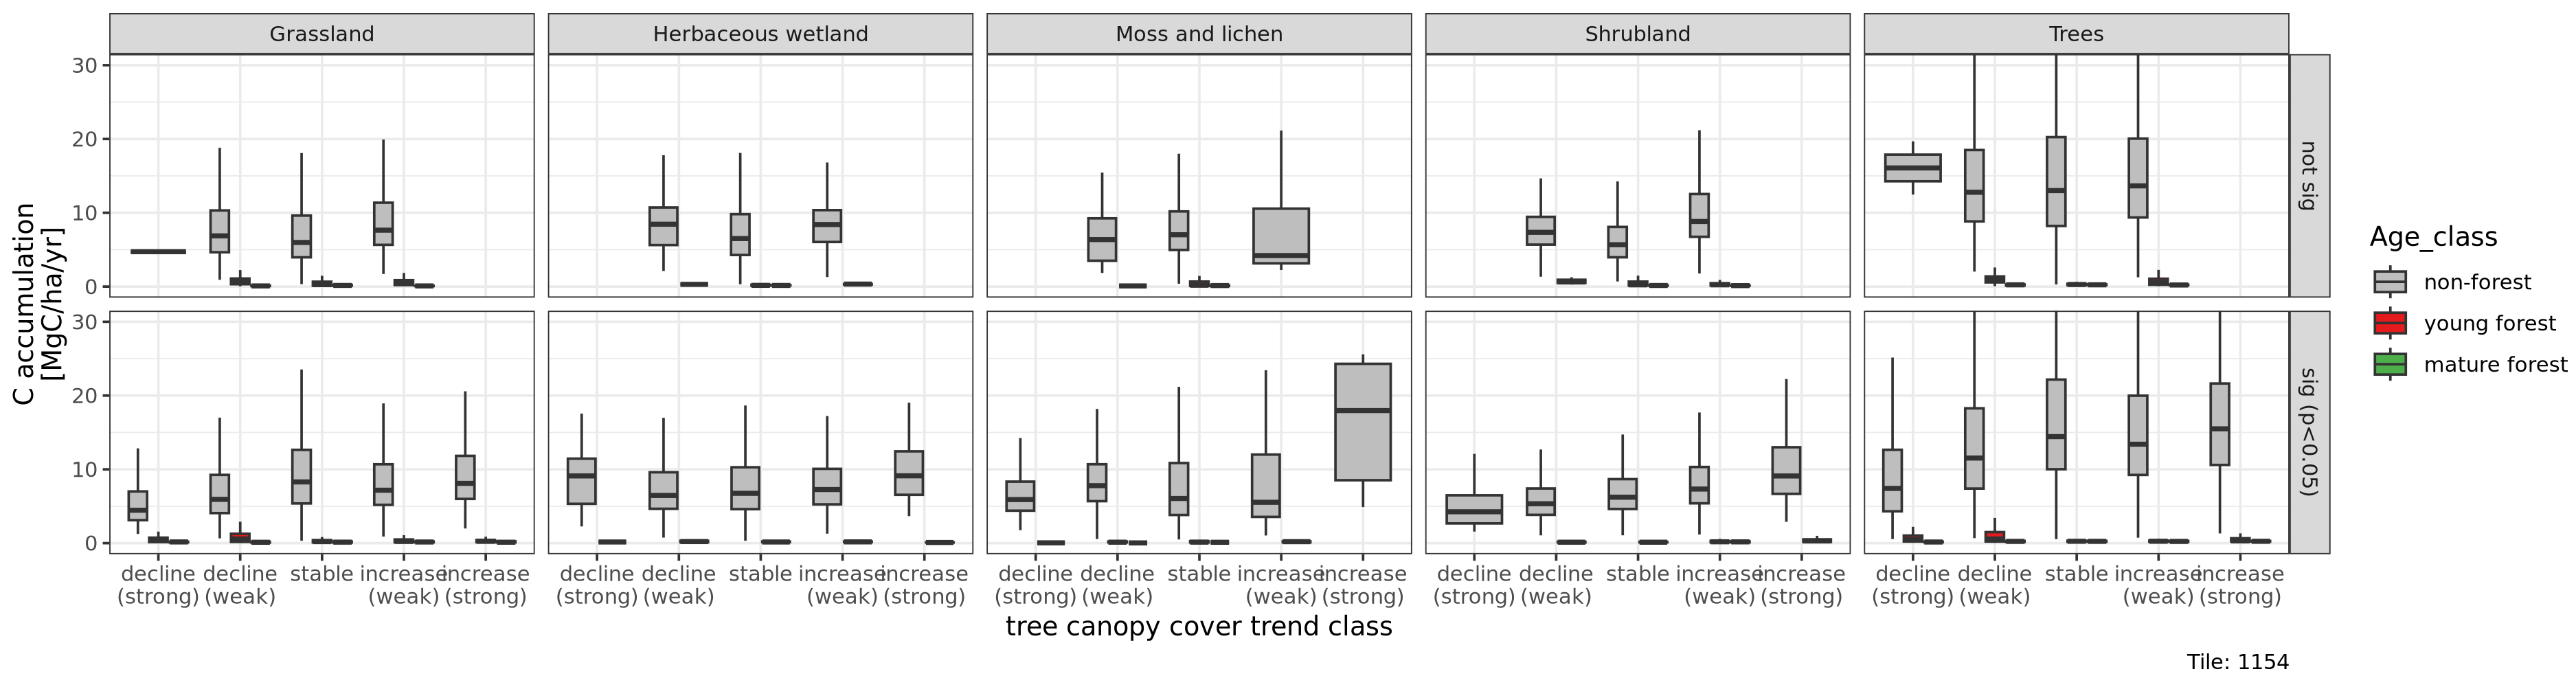

In [91]:
options(repr.plot.width = 15, repr.plot.height = 4, repr.plot.res = 250)

Y_VAR = 'Mg_C_ha_yr'

ggplot(TMP_DF, aes( x=TCC_trend_class, y = .data[[Y_VAR]], fill=Age_class) ) + 
    geom_boxplot(outlier.shape=' ') + 
    scale_fill_manual(values=colors_standage, name='Age class')+ 
    coord_cartesian(ylim=c(0,30))+ 
    facet_grid(TCC_trend_pval_class ~ LC)+ 
    theme_bw() +
    labs(x='tree canopy cover trend class', y='C accumulation\n[MgC/ha/yr]', caption=paste0('Tile: ',TILE_NUM))

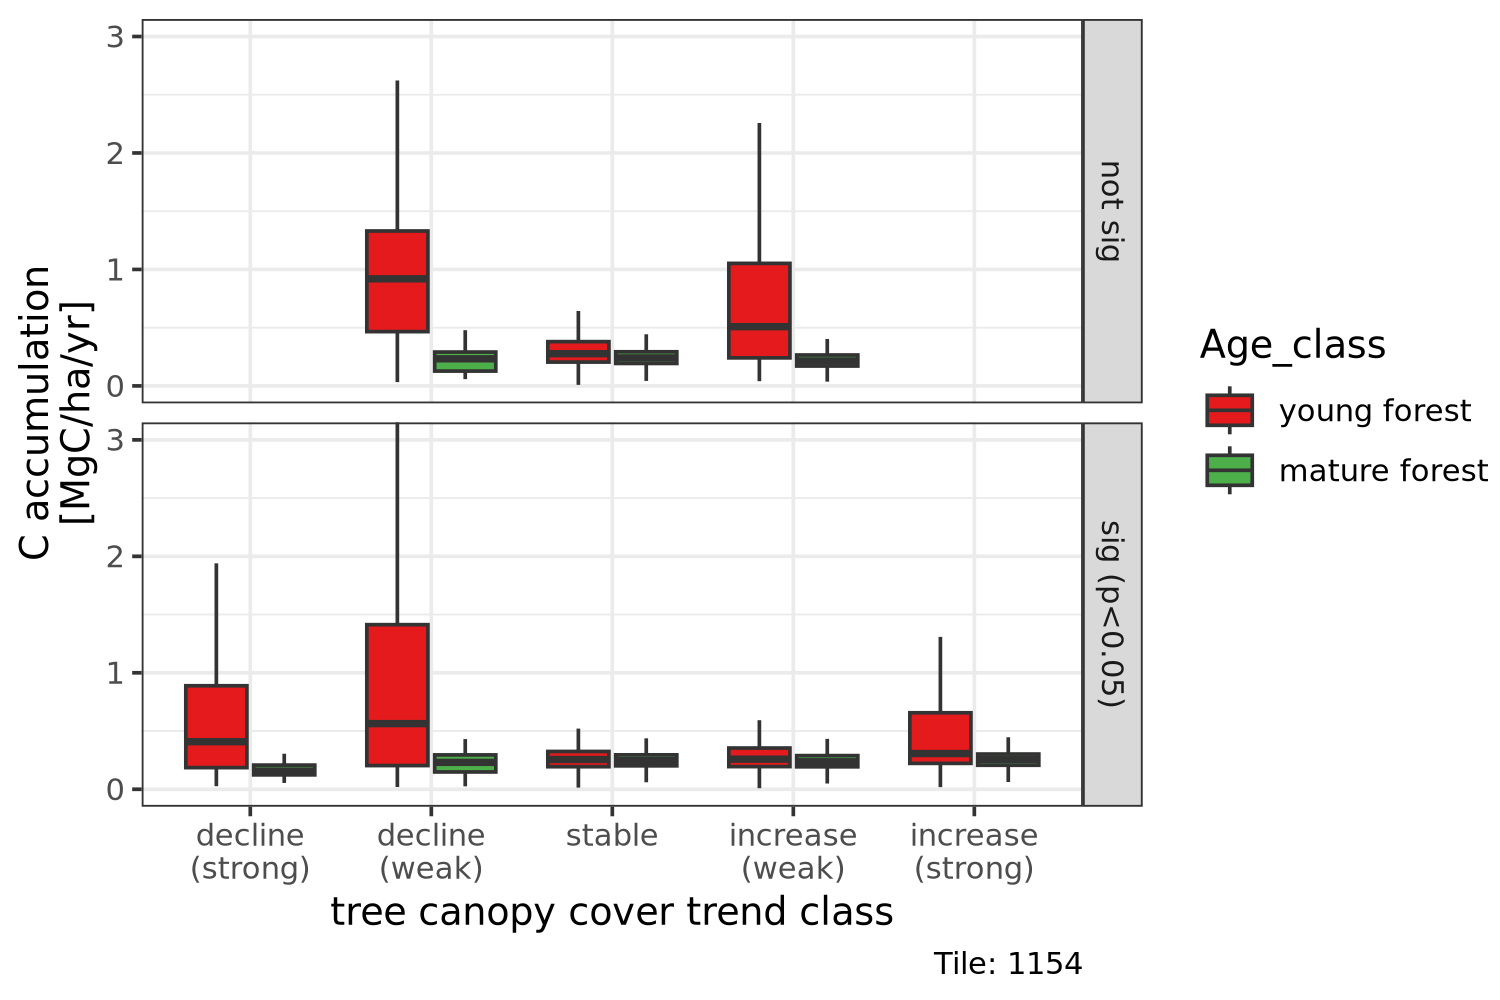

In [30]:
options(repr.plot.width = 6, repr.plot.height = 4, repr.plot.res = 250)

Y_VAR = 'Mg_C_ha_yr'

ggplot(TMP_DF %>% filter(Age_class != 'non-forest'), aes( x=TCC_trend_class, y = .data[[Y_VAR]], fill=Age_class) ) + 
    geom_boxplot(outlier.shape=' ') + 
    scale_fill_manual(values=colors_standage, name='Age class')+ 
    coord_cartesian(ylim=c(0,3))+ 
    facet_grid(TCC_trend_pval_class ~ .)+ 
    theme_bw() +
    labs(x='tree canopy cover trend class', y='C accumulation\n[MgC/ha/yr]', caption=paste0('Tile: ',TILE_NUM))

Warning message:
“Transformation introduced infinite values in discrete y-axis”
Warning message:
“Removed 514 rows containing missing values (`geom_point()`).”


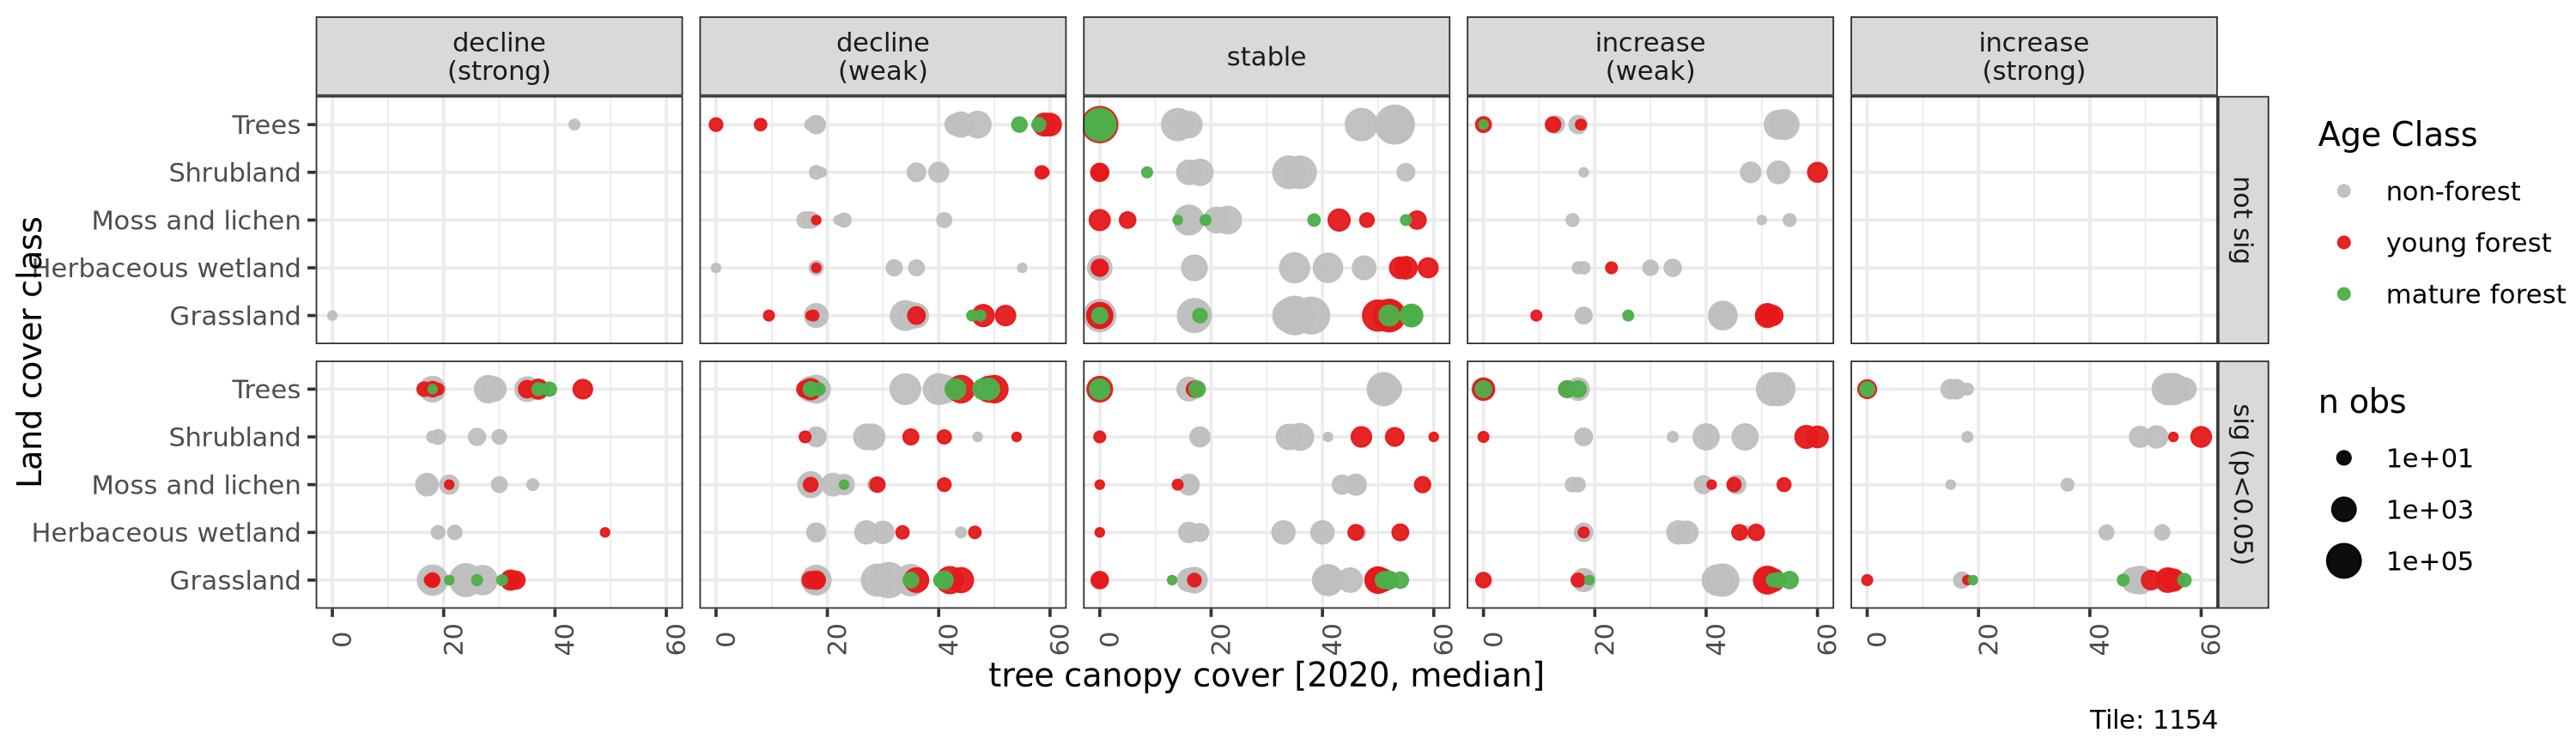

In [90]:
options(repr.plot.width = 12, repr.plot.height = 3.5, repr.plot.res = 250)
ggplot(
       TMP_SMRY_DF, aes(y=LC, x=`TCC_2020 median`, color=Age_class) ) +
    #+ geom_pointrange(aes(ymin='TCC_2020 std', ymax='TCC_2020 std'), alpha=0.5)
    geom_point(aes(size=`TCC_2020 count`), alpha=0.95) +
    #+ scale_size(trans='log10',breaks=(1e1,1e6), name='n obs')
    scale_radius(trans='log10', breaks=c(1e1,1e3,1e5), name='n obs')+
    scale_x_continuous(limits=c(0,60))+
    scale_color_manual(values=colors_standage, name = 'Age class')+
    theme_bw()+
    #+ facet_wrap('~ TCC_trend_pval_class + TCC_trend_class', ncol=5)
    facet_grid(TCC_trend_pval_class ~ TCC_trend_class)+
    theme(axis.text.x = element_text(angle=90)) +
    labs(x='tree canopy cover [2020, median]', y='Land cover class', caption=paste0('Tile: ',TILE_NUM))

### Smry explaining the TP 'non-forest' class (important b/c it gets an Age of 0, adjusted to 0.5)
Take-home re TP 'non-forest': 
+ it still has 'Treed' LC
+ most is non 'Treed' LC
+ generall below 30% TCC 

### Total biomass by stand age, tree cover trend class, significance class
biomass patterns across age and structural trend groupings

In [90]:
#stack_df_smry %>% filter(!(LC %in% FILTER_LIST))

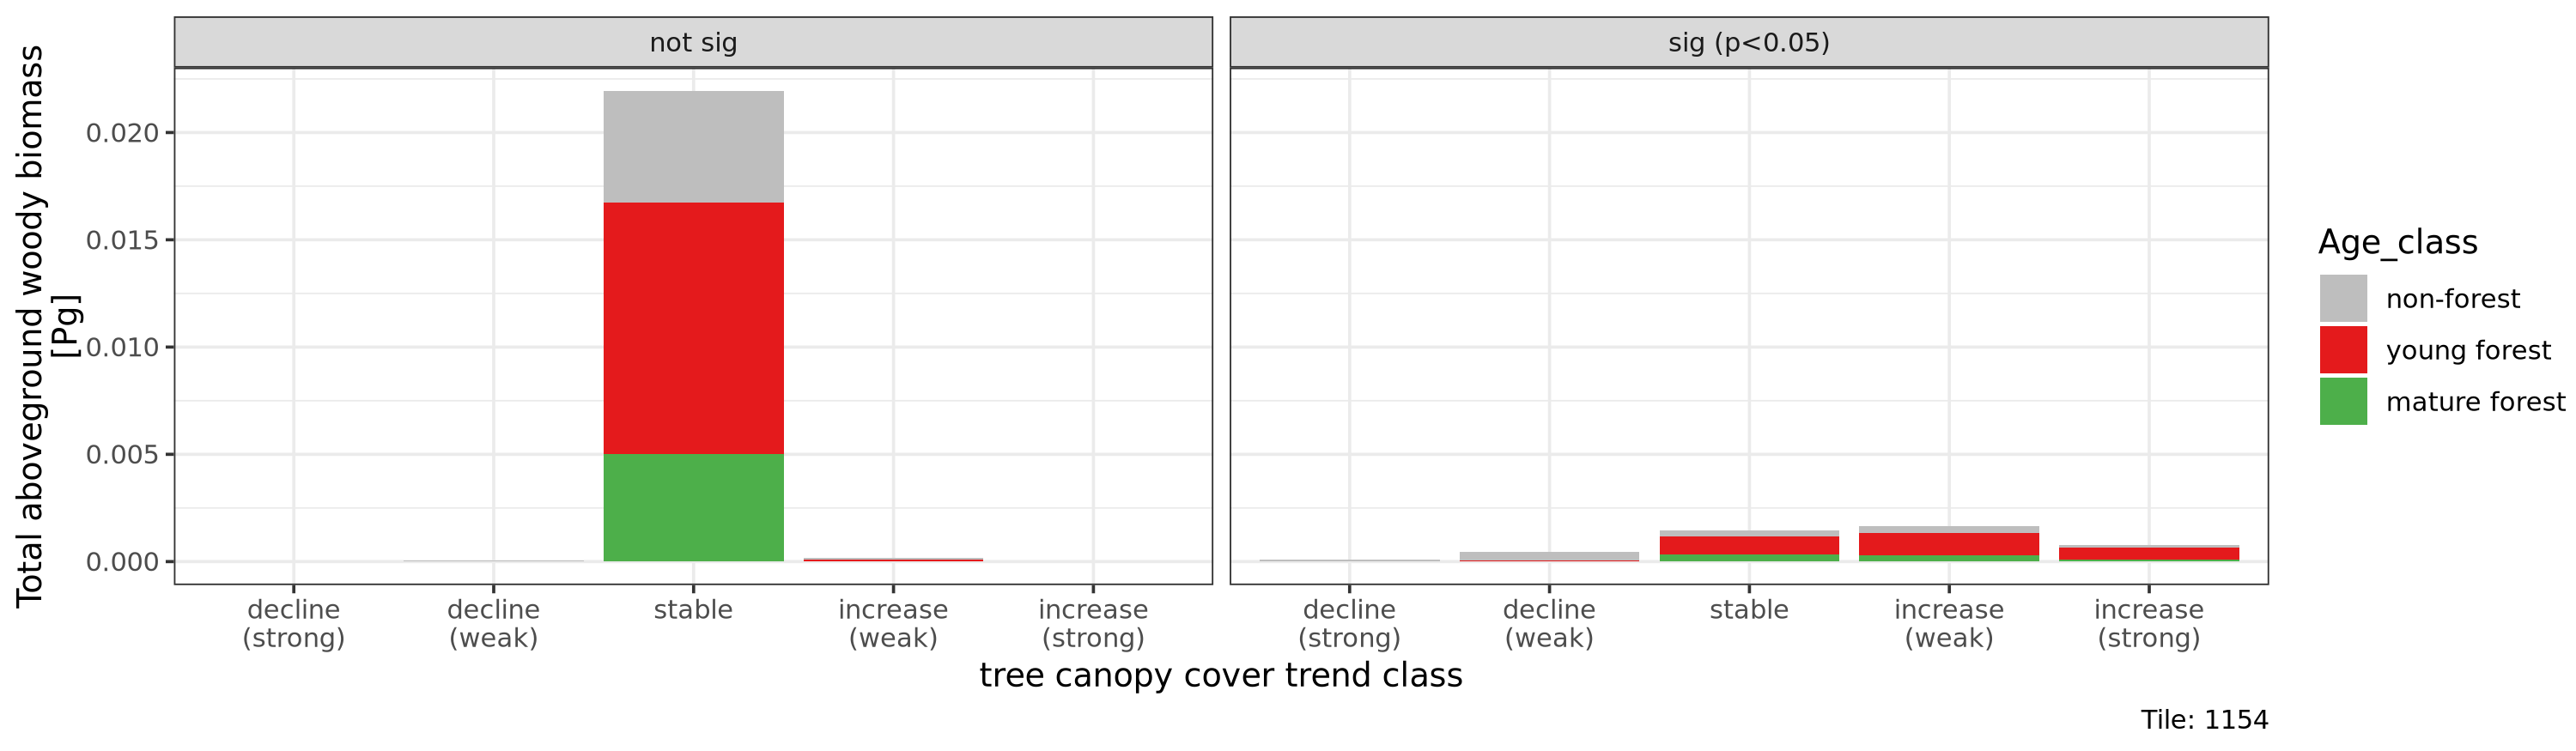

In [87]:
options(repr.plot.width = 12, repr.plot.height = 3.5, repr.plot.res = 250)

ggplot(TMP_SMRY_DF, aes(y=`Total AGB [Pg]`, x=TCC_trend_class, fill=Age_class) ) +
    geom_bar(stat='identity') +
    scale_fill_manual(values=colors_standage, name='Age class') +
        facet_wrap(.~ TCC_trend_pval_class, ncol=3) + 
    theme_bw() +
    labs(x='tree canopy cover trend class', y='Total aboveground woody biomass\n[Pg]', caption=paste0('Tile: ',TILE_NUM))

What proportion of `Total AGB`

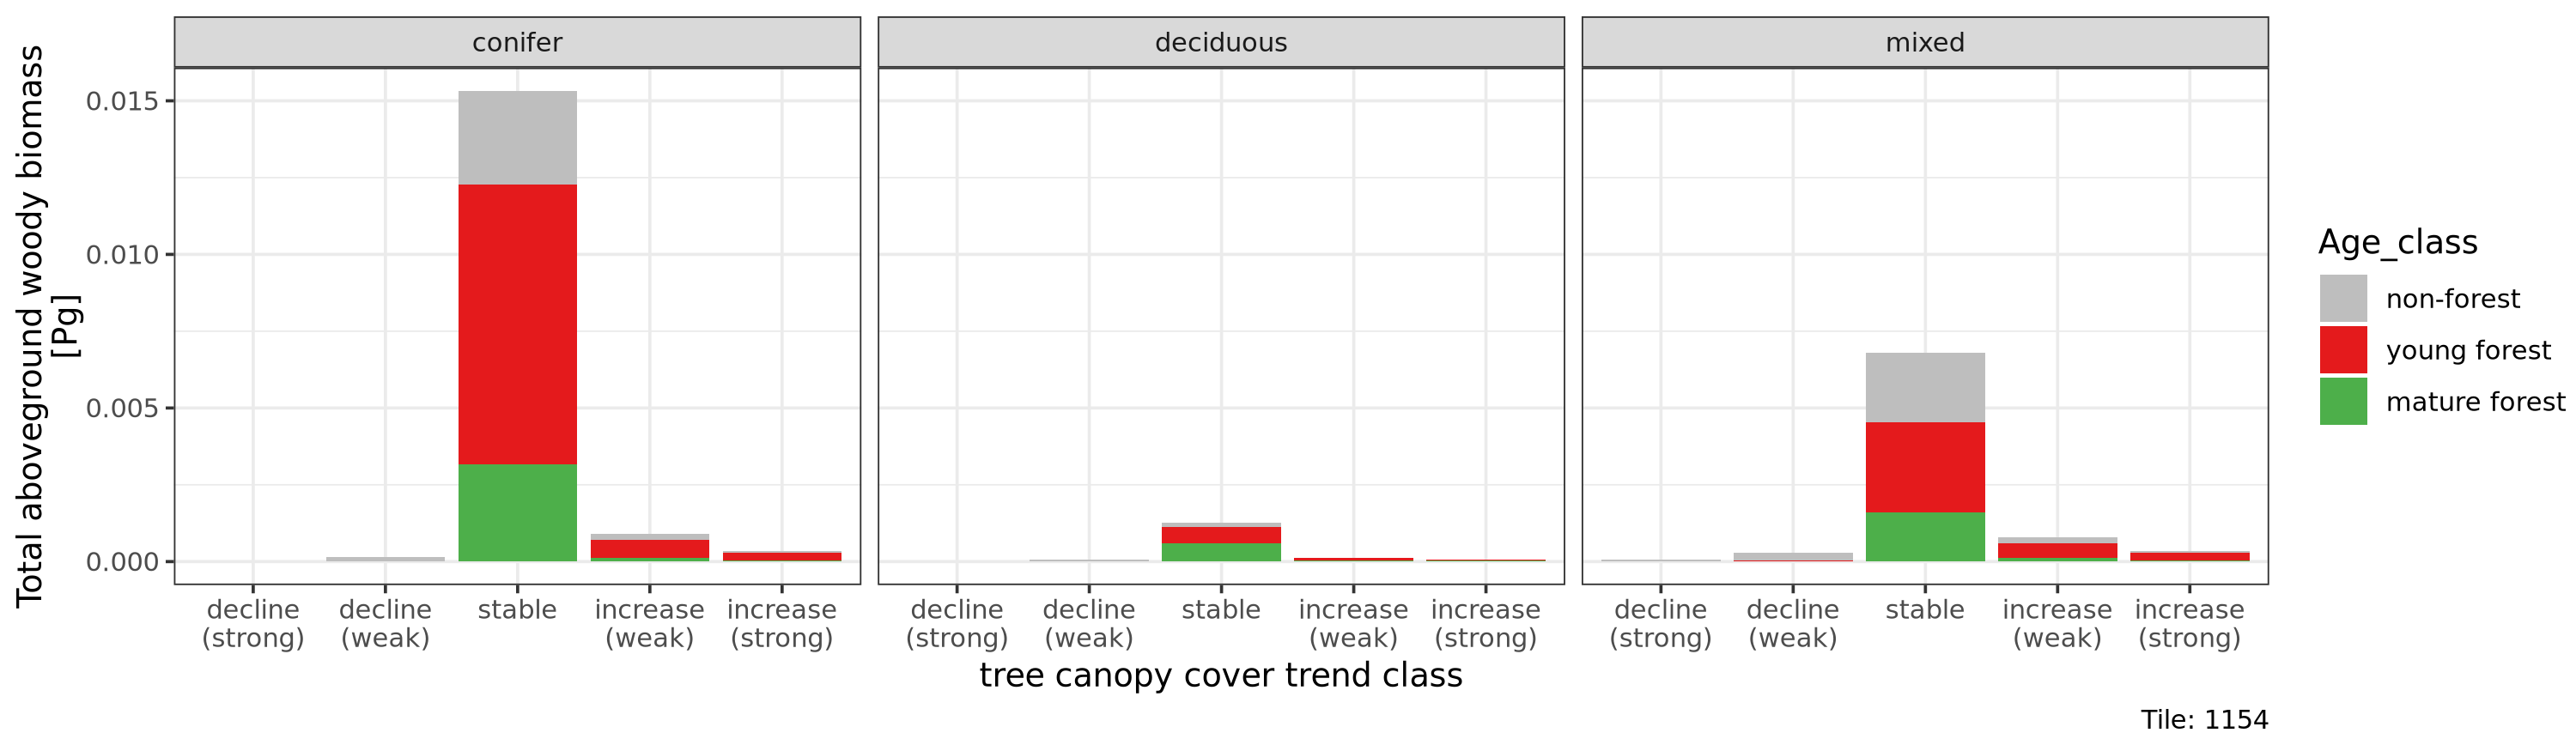

In [86]:
options(repr.plot.width =12, repr.plot.height = 3.5, repr.plot.res = 250)

ggplot(TMP_SMRY_DF, aes(y=`Total AGB [Pg]`, x=TCC_trend_class, fill=Age_class) ) +
    geom_bar(stat='identity') +
    scale_fill_manual(values=colors_standage, name='Age class') +
        facet_wrap(.~ DecidPred2015_class, ncol=3) + 
    theme_bw() +
    labs(x='tree canopy cover trend class', y='Total aboveground woody biomass\n[Pg]', caption=paste0('Tile: ',TILE_NUM))

Warning message:
“Removed 3 rows containing non-finite values (`stat_boxplot()`).”


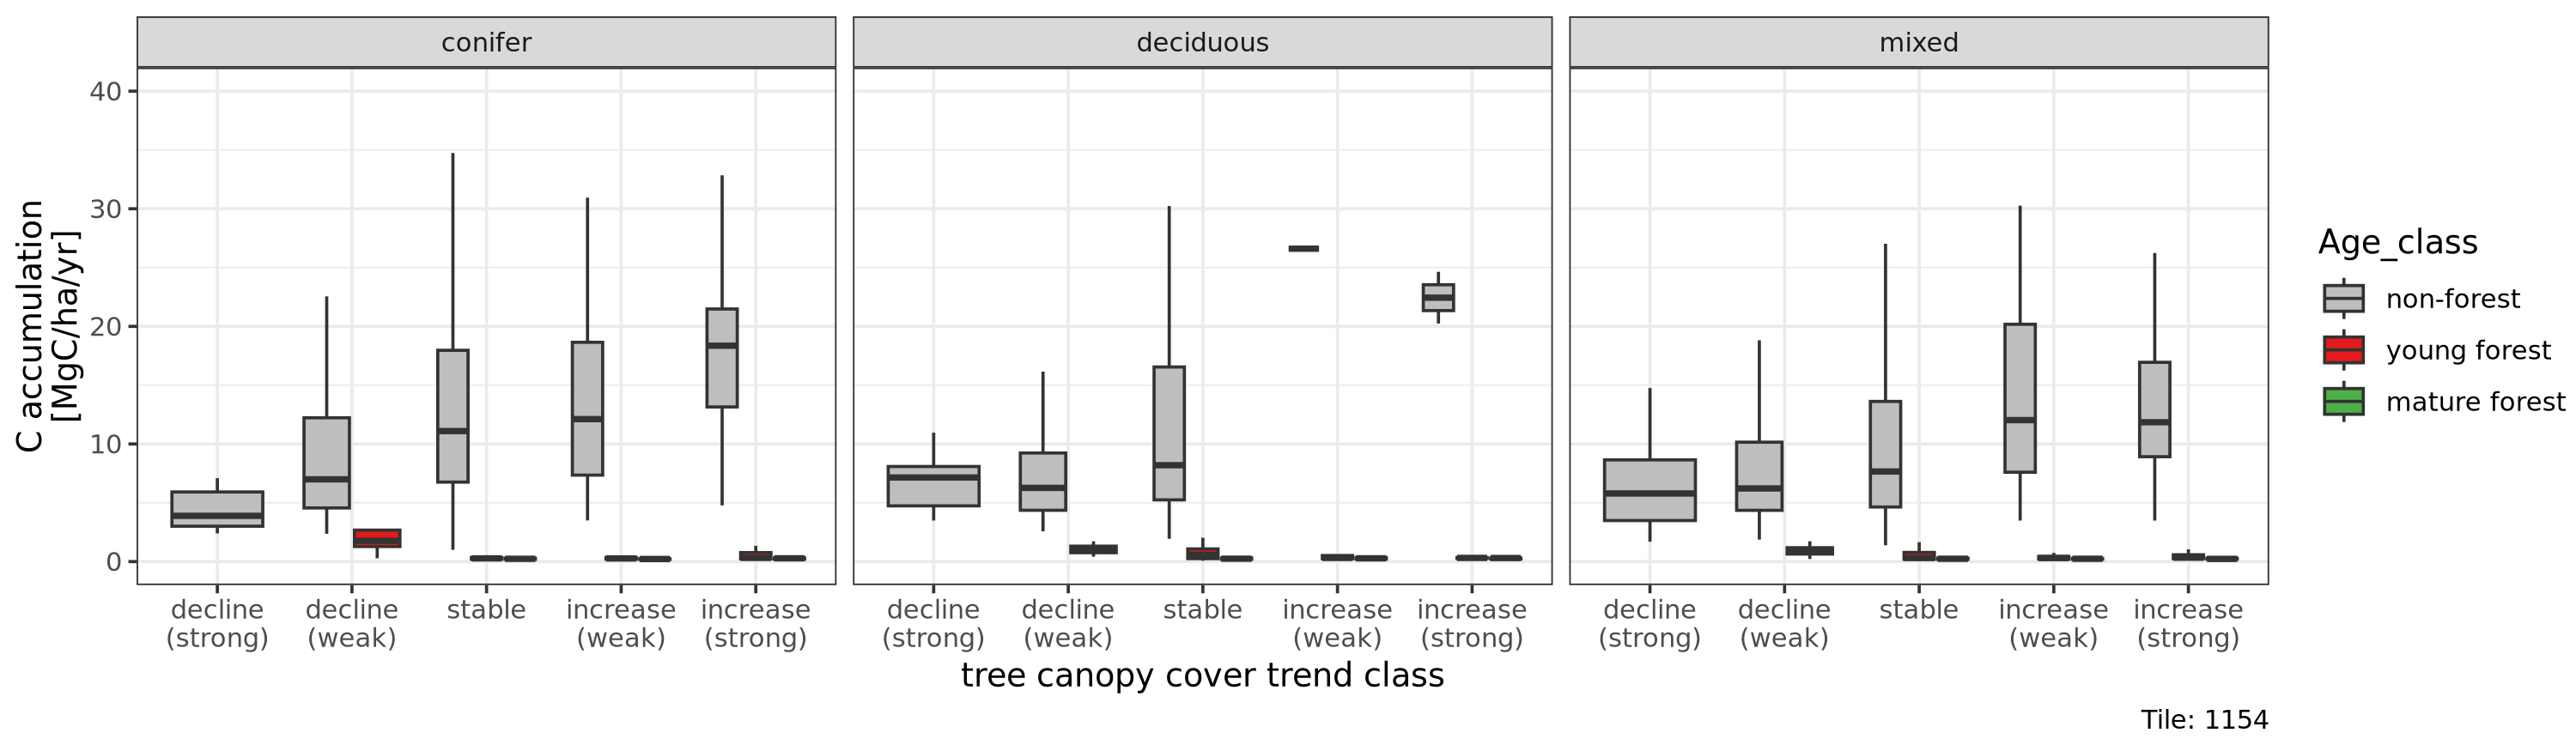

In [88]:
options(repr.plot.width = 12, repr.plot.height = 3.5, repr.plot.res = 250)

ggplot(TMP_DF, aes(y=Mg_C_ha_yr, x=TCC_trend_class, fill=Age_class) ) +
    #geom_point(size=0.5) +
    geom_boxplot(outlier.size=-1) +
    scale_y_continuous(limits=c(0,40)) +
    #scale_color_manual(values=colors_standage) +
    scale_fill_manual(values=colors_standage, name='Age class') +
    facet_wrap(.~ DecidPred2015_class, ncol=3) + 
    theme_bw() +
    #geom_text(aes(x=Inf, y=40, label=TILE_NUM), hjust=2, vjust=0) +
    labs(x='tree canopy cover trend class', y='C accumulation\n[MgC/ha/yr]', caption=paste0('Tile: ',TILE_NUM))

In [110]:
options(repr.plot.width = 8, repr.plot.height = 5, repr.plot.res = 250)

TMP_DF$Age_interval = factor(TMP_DF$Age_interval , levels=c('non-forest','1-20','21-40','41-60','61-80','81-100','101-120','121-140','141-160','161-180','181-200','>200'))

Y_VAR = 'Mg_C_ha_yr'

ggplot(TMP_DF %>% filter(Age_class != 'non-forest'), aes( x=Age_interval, y = .data[[Y_VAR]], fill=TCC_trend_class) ) + 
    geom_boxplot(outlier.shape=' ') + 
    scale_fill_manual(values=colors_tcctrend, name='tree canopy cover\ntrend class')+ 
    coord_cartesian(ylim=c(0, 2.0))+ 
    facet_grid(TCC_trend_pval_class ~ .)+ 
    theme_bw() +
    labs(x='Age 2020 interval', y='C accumulation\n[MgC/ha/yr]', caption=paste0('Tile: ',TILE_NUM))